In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

df.columns = df.columns.str.strip()

df.rename(columns={
    'Region': 'State',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Region.1': 'Region'
}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

print("Dataset Shape")
print(df.shape)

print("\nMissing Values Count")
print(df.isnull().sum())

print("\nCleaned DataFrame Preview")
df.head()

Dataset Shape
(267, 9)

Missing Values Count
State                        0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Region                       0
longitude                    0
latitude                     0
dtype: int64

Cleaned DataFrame Preview


,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region,longitude,latitude
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74


Statistical Summary


,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


C:\Users\admin\AppData\Local\Temp\ipykernel_9068\1377614619.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x='Unemployment_Rate', y='State', palette='Reds_r')


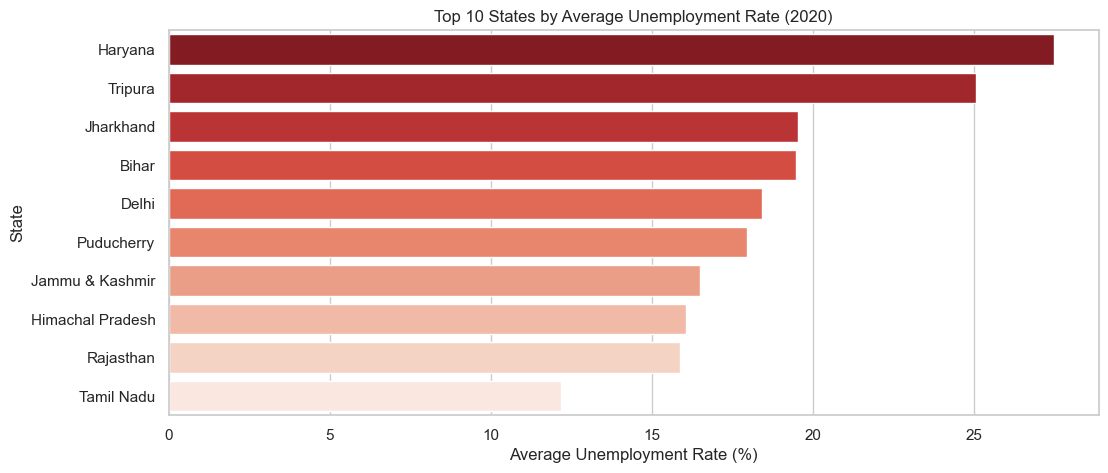

C:\Users\admin\AppData\Local\Temp\ipykernel_9068\1377614619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Region', y='Unemployment_Rate', palette='Set2')


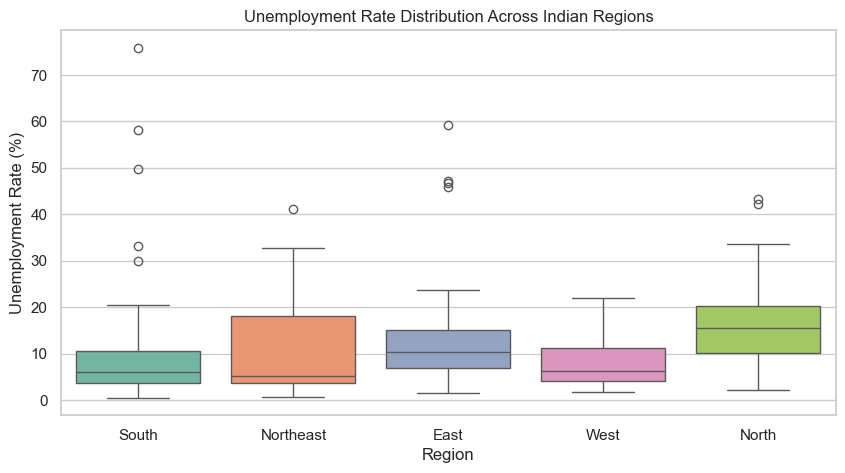

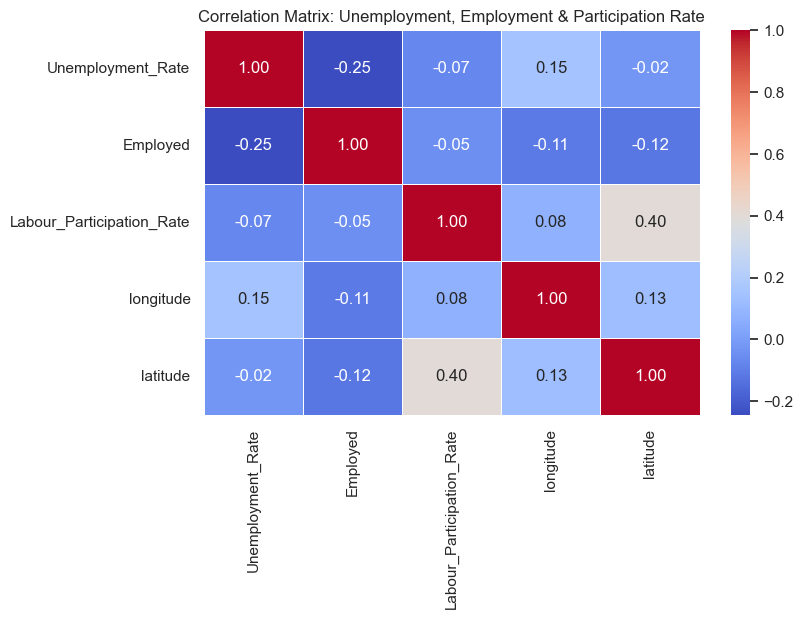

In [2]:
print("Statistical Summary")
display(df.describe())

top_states = (
    df.groupby('State')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_states, x='Unemployment_Rate', y='State', palette='Reds_r')
plt.title("Top 10 States by Average Unemployment Rate (2020)")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Region', y='Unemployment_Rate', palette='Set2')
plt.title("Unemployment Rate Distribution Across Indian Regions")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.show()

plt.figure(figsize=(8, 5))
corr_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate', 'longitude', 'latitude']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Unemployment, Employment & Participation Rate")
plt.show()

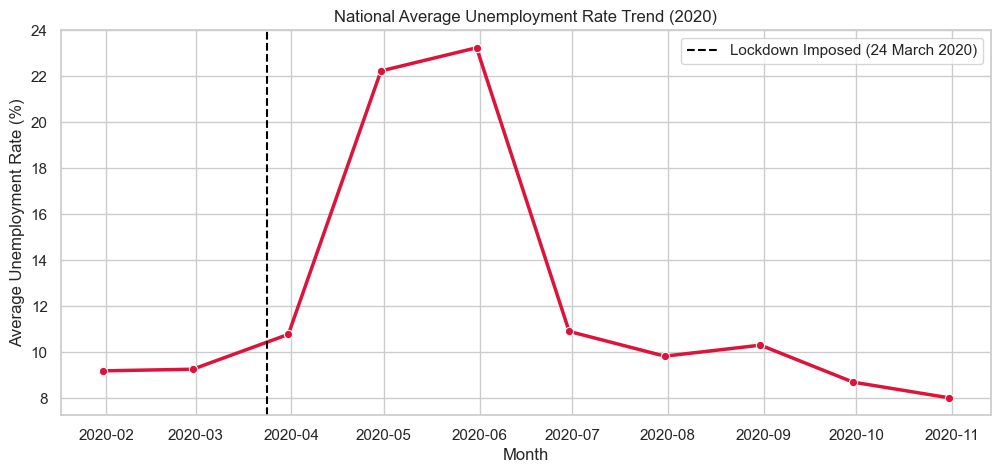

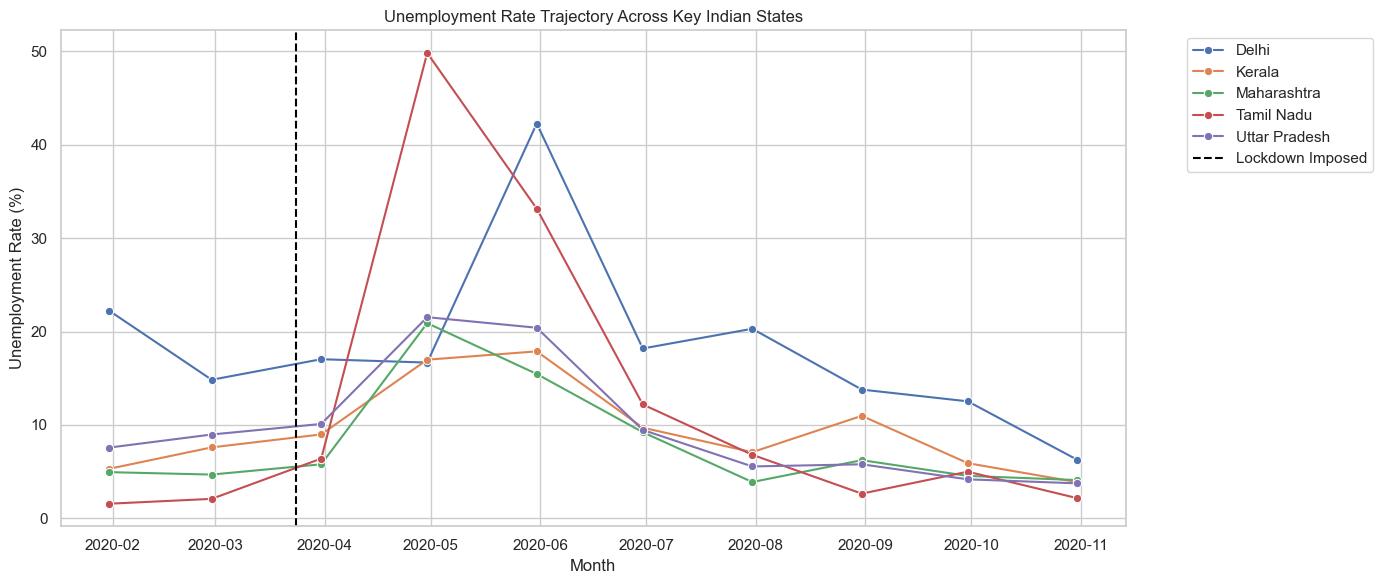

COVID-19 Impact Summary
Mean Unemployment Rate Pre-COVID (Jan 2020 - Mar 2020):   9.76%
Mean Unemployment Rate During/Post-COVID Lockdown:         13.28%
Absolute Increase in Unemployment Rate:                    3.52%


In [3]:
monthly_trend = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trend, x='Date', y='Unemployment_Rate', marker='o', color='crimson', linewidth=2.5)
plt.axvline(pd.to_datetime('2020-03-24'), color='black', linestyle='--', label='Lockdown Imposed (24 March 2020)')
plt.title("National Average Unemployment Rate Trend (2020)")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()
plt.show()

selected_states = ['Maharashtra', 'Tamil Nadu', 'Delhi', 'Uttar Pradesh', 'Kerala']
df_selected = df[df['State'].isin(selected_states)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_selected, x='Date', y='Unemployment_Rate', hue='State', marker='o')
plt.axvline(pd.to_datetime('2020-03-24'), color='black', linestyle='--', label='Lockdown Imposed')
plt.title("Unemployment Rate Trajectory Across Key Indian States")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

pre_covid = df[df['Date'] < '2020-04-01']
post_covid = df[df['Date'] >= '2020-04-01']

pre_mean = pre_covid['Unemployment_Rate'].mean()
post_mean = post_covid['Unemployment_Rate'].mean()

print("COVID-19 Impact Summary")
print(f"Mean Unemployment Rate Pre-COVID (Jan 2020 - Mar 2020):   {pre_mean:.2f}%")
print(f"Mean Unemployment Rate During/Post-COVID Lockdown:         {post_mean:.2f}%")
print(f"Absolute Increase in Unemployment Rate:                    {post_mean - pre_mean:.2f}%")